In [91]:
from scipy import signal
import numpy as np
import pycatch22
import tsfresh
from scipy import ndimage

import matplotlib.pyplot as plt

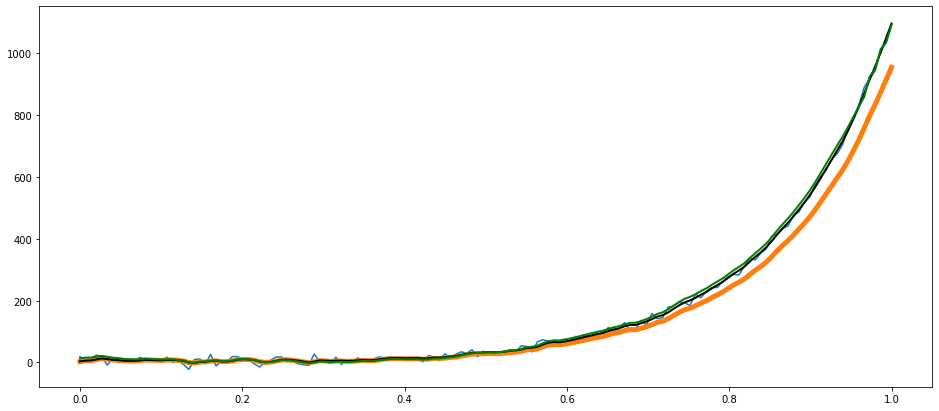

In [116]:
# create a noisy signal wit an increasing trend
np.random.seed(0)
a = 7
b = 10
f = 0.1
window = 5
t = np.linspace(0, 1, 150)
x = np.exp(a*t) + b*np.random.normal(size=150)

# create a low-pass butterworth filter
passfilter = signal.butter(1, f, btype='low',analog=False, output='sos')
filtered = signal.sosfilt(passfilter, x) 
detrended = x-np.exp(a*t)

trended_approx = ndimage.gaussian_filter1d(x, window)
trended_approx[-window:] = x[-window:]

detrended_approx = x - trended_approx 
filtered_detrended = signal.sosfilt(passfilter, detrended) + np.exp(a*t)
filtered_detrended_approx = signal.sosfilt(passfilter, detrended) + trended_approx


plt.figure(figsize=(16, 7))
plt.plot(t, x, label='Noisy signal')
plt.plot(t, filtered, label='Filtered signal', lw=5)
plt.plot(t, filtered_detrended, label='Filtered signal, detrended', lw=2, color='black')
plt.plot(t, filtered_detrended_approx, label='Filtered signal, detrended approx', lw=2, color='green')


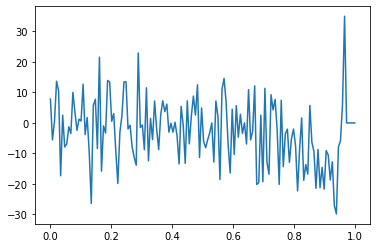

In [117]:
plt.plot(t, detrended_approx)